# Load Library

In [54]:
# Core Libraries
import cudf  # GPU-accelerated dataframe
import cupy as cp  # GPU-accelerated numerical computing
import numpy as np  # Numerical computing
import pandas as pd  # Fallback for CPU operations
import seaborn as sns

# Data Processing
from cuml.preprocessing import MinMaxScaler  # GPU-accelerated scaling
from sklearn.model_selection import train_test_split  # Fallback for data splitting

import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Print library versions
print(f"cuDF Version: {cudf.__version__}")
print(f"CuPy Version: {cp.__version__}")

# GPU Check
from numba import cuda

if cuda.is_available():
    print("\nGPU Detected:")
    device = cuda.get_current_device()
    print(f"Device Name: {device.name}") 
else:
    print("Warning: No GPU detected - Falling back to CPU mode")

cuDF Version: 24.10.01
CuPy Version: 13.3.0

GPU Detected:
Device Name: b'NVIDIA GeForce RTX 4050 Laptop GPU'


# Load Dataset

In [55]:
def load_datasets():
    """
    Memuat dataset Harga.csv dan Triwulan.csv dengan cudf.
    Mengembalikan tuple (harga_df, triwulan_df).
    """
    try:
        # Load Harga.csv (data harian)
        harga_df = cudf.read_csv('harga.csv', parse_dates=['Tanggal'], skipinitialspace=True)
        
        # Load Triwulan.csv (data produksi)
        triwulan_df = cudf.read_csv('produksi.csv', skipinitialspace=True)
        
        # Validasi keberadaan kolom penting
        required_harga_cols = {'Komoditi', 'Tanggal', ' Harga Petani ', ' Harga Pengecer '}
        required_triwulan_cols = {'Komoditi', 'tahun', 'triwulan', 'Luas Panen', 'Produktivitas', 'Produksi'}
        
        assert required_harga_cols.issubset(harga_df.columns), "Kolom tidak valid di Harga.csv"
        assert required_triwulan_cols.issubset(triwulan_df.columns), "Kolom tidak valid di Triwulan.csv"
        
        print("✔ Dataset berhasil dimuat")
        print(f"- Harga.csv: {len(harga_df)} baris")
        print(f"- Triwulan.csv: {len(triwulan_df)} baris")
        
        return harga_df, triwulan_df
    
    except FileNotFoundError as e:
        print(f"❌ File tidak ditemukan: {e}")
        return None, None
    except Exception as e:
        print(f"❌ Error saat memuat dataset: {e}")
        return None, None

# Contoh penggunaan
harga_df, triwulan_df = load_datasets()

if harga_df is not None:
    print("\n5 baris pertama harga.csv:")
    print(harga_df.head())

if triwulan_df is not None:
    print("\n5 baris pertama Produksi.csv:")
    print(triwulan_df.head())

✔ Dataset berhasil dimuat
- Harga.csv: 4382 baris
- Triwulan.csv: 30 baris

5 baris pertama harga.csv:
              Komoditi    Tanggal   Harga Petani    Harga Pengecer 
0  Jagung Pipil Kering 2022-01-03            4800              5000
1  Jagung Pipil Kering 2022-01-04            4800              5000
2  Jagung Pipil Kering 2022-01-05            4800              5000
3  Jagung Pipil Kering 2022-01-06            4800              5000
4  Jagung Pipil Kering 2022-01-07            4800              5000

5 baris pertama Produksi.csv:
     Komoditi  tahun  triwulan  Luas Panen  Produktivitas   Produksi
0  Padi sawah   2022         1  35685.6200      56.593625  201957.86
1  Padi sawah   2022         2  12599.0000      54.279752   68387.06
2  Padi sawah   2022         3   6888.7897      55.240632   38054.11
3  Padi sawah   2023         1  26790.3606      55.977470  149965.66
4  Padi sawah   2023         2  21687.8044      58.797478  127518.82


In [56]:
harga_df = harga_df.rename(columns={
    ' Harga Petani ': 'Harga Petani',
    ' Harga Pengecer ': 'Harga Pengecer'
})

In [57]:
triwulan_df.head()

,Komoditi,tahun,triwulan,Luas Panen,Produktivitas,Produksi
0,Padi sawah,2022,1,35685.6200,56.593625,201957.86
1,Padi sawah,2022,2,12599.0000,54.279752,68387.06
2,Padi sawah,2022,3,6888.7897,55.240632,38054.11
3,Padi sawah,2023,1,26790.3606,55.977470,149965.66
4,Padi sawah,2023,2,21687.8044,58.797478,127518.82


In [58]:
df_sorted = harga_df.sort_values(by='Komoditi')
df_sorted.reset_index(drop=True, inplace=True)


In [59]:
df_sorted

,Komoditi,Tanggal,Harga Petani,Harga Pengecer
0,Beras Medium,2022-01-01,<NA>,<NA>
1,Beras Medium,2022-01-02,<NA>,<NA>
2,Beras Medium,2022-01-03,8800,9000
3,Beras Medium,2022-01-04,8800,9000
4,Beras Medium,2022-01-05,8800,9000
...,...,...,...,...
4377,Kacang Hijau,2024-12-27,13000,15000
4378,Kacang Hijau,2024-12-28,13000,15000
4379,Kacang Hijau,2024-12-29,13000,15000
4380,Kacang Hijau,2024-12-30,<NA>,<NA>


In [60]:
harga_df['Komoditi'].unique()

0    Jagung Pipil Kering
1           Beras Medium
2          Beras Premium
3           Kacang Hijau
Name: Komoditi, dtype: object

In [61]:
triwulan_df['Komoditi'].unique()

0      Padi sawah
1       padi gogo
2      padi total
3          jagung
4    kacang hijau
Name: Komoditi, dtype: object

In [62]:
harga_jagung=harga_df[harga_df['Komoditi'] == 'Jagung Pipil Kering']
harga_beras_medium=harga_df[harga_df['Komoditi'] == 'Beras Medium']
harga_beras_premium=harga_df[harga_df['Komoditi'] == 'Beras Premium']
harga_kacang_hijau=harga_df[harga_df['Komoditi'] == 'Kacang Hijau']

# Analisis Deskriptif

In [63]:
def explore_harga_data(harga_df):
    """
    Melakukan eksplorasi data pada DataFrame harga_df.
    """
    # 1. Cek kolom dan tipe data
    print("1. Kolom dan Tipe Data:")
    print(harga_df.dtypes)
    print("\n")

    # 2. Cek data duplikat
    duplicate_count = harga_df.duplicated().sum()
    print(f"2. Jumlah Data Duplikat: {duplicate_count}")
    print("\n")

    # 3. Cek missing values
    missing_values = harga_df.isnull().sum()
    print("3. Missing Values:")
    print(missing_values[missing_values > 0])  # Hanya tampilkan kolom dengan missing values
    print("\n")

    # 4. Ringkasan Statistik untuk Data Numerik
    print("4. Ringkasan Statistik (Data Numerik):")
    print(harga_df.describe())
    print("\n")

    # 5. Ringkasan Statistik untuk Data Kategorikal
    print("5. Ringkasan Statistik (Data Kategorikal):")
    categorical_summary = harga_df.describe(include=['object', 'category'])
    print(categorical_summary)
    print("\n")

In [64]:
explore_harga_data(harga_beras_medium)

1. Kolom dan Tipe Data:
Komoditi                  object
Tanggal           datetime64[ns]
Harga Petani               int64
Harga Pengecer             int64
dtype: object


2. Jumlah Data Duplikat: 0


3. Missing Values:
Harga Petani      363
Harga Pengecer    362
dtype: int64


4. Ringkasan Statistik (Data Numerik):
                             Tanggal  Harga Petani  Harga Pengecer
count                           1096    733.000000      734.000000
mean             2023-07-02 12:00:00  10585.402456    11468.119891
min              2022-01-01 00:00:00   8200.000000     9000.000000
25%    2022-10-01 18:00:00.000000000   8800.000000     9000.000000
50%    2023-07-02 12:00:00.000000000   9700.000000    10900.000000
75%    2024-04-01 06:00:00.000000000  12500.000000    13500.000000
max              2024-12-31 00:00:00  15000.000000    16000.000000
std                             <NA>   1930.292670     2217.681029


5. Ringkasan Statistik (Data Kategorikal):
            Komoditi
count        

In [65]:
harga_beras_medium.describe()

,Tanggal,Harga Petani,Harga Pengecer
count,1096,733.000000,734.000000
mean,2023-07-02 12:00:00,10585.402456,11468.119891
min,2022-01-01 00:00:00,8200.000000,9000.000000
25%,2022-10-01 18:00:00.000000000,8800.000000,9000.000000
50%,2023-07-02 12:00:00.000000000,9700.000000,10900.000000
75%,2024-04-01 06:00:00.000000000,12500.000000,13500.000000
max,2024-12-31 00:00:00,15000.000000,16000.000000
std,<NA>,1930.292670,2217.681029


In [66]:
explore_harga_data(harga_beras_premium)

1. Kolom dan Tipe Data:
Komoditi                  object
Tanggal           datetime64[ns]
Harga Petani               int64
Harga Pengecer             int64
dtype: object


2. Jumlah Data Duplikat: 0


3. Missing Values:
Harga Petani      368
Harga Pengecer    368
dtype: int64


4. Ringkasan Statistik (Data Numerik):
                             Tanggal  Harga Petani  Harga Pengecer
count                           1096    728.000000      728.000000
mean             2023-07-02 12:00:00  11488.461538    12427.609890
min              2022-01-01 00:00:00   9500.000000     9800.000000
25%    2022-10-01 18:00:00.000000000   9500.000000    10000.000000
50%    2023-07-02 12:00:00.000000000  10700.000000    11900.000000
75%    2024-04-01 06:00:00.000000000  13000.000000    14600.000000
max              2024-12-31 00:00:00  15500.000000    17500.000000
std                             <NA>   1874.927996     2123.548146


5. Ringkasan Statistik (Data Kategorikal):
             Komoditi
count       

In [67]:
harga_beras_premium.describe()

,Tanggal,Harga Petani,Harga Pengecer
count,1096,728.000000,728.000000
mean,2023-07-02 12:00:00,11488.461538,12427.609890
min,2022-01-01 00:00:00,9500.000000,9800.000000
25%,2022-10-01 18:00:00.000000000,9500.000000,10000.000000
50%,2023-07-02 12:00:00.000000000,10700.000000,11900.000000
75%,2024-04-01 06:00:00.000000000,13000.000000,14600.000000
max,2024-12-31 00:00:00,15500.000000,17500.000000
std,<NA>,1874.927996,2123.548146


In [68]:
explore_harga_data(harga_jagung)

1. Kolom dan Tipe Data:
Komoditi                  object
Tanggal           datetime64[ns]
Harga Petani               int64
Harga Pengecer             int64
dtype: object


2. Jumlah Data Duplikat: 0


3. Missing Values:
Harga Petani      363
Harga Pengecer    363
dtype: int64


4. Ringkasan Statistik (Data Numerik):
                             Tanggal  Harga Petani  Harga Pengecer
count                           1094    731.000000      731.000000
mean             2023-07-03 12:00:00   4501.641587     4820.930233
min              2022-01-03 00:00:00   3300.000000     3600.000000
25%    2022-10-03 06:00:00.000000000   3800.000000     4000.000000
50%    2023-07-03 12:00:00.000000000   4300.000000     4700.000000
75%    2024-04-01 18:00:00.000000000   4800.000000     5000.000000
max              2024-12-31 00:00:00   8000.000000     8500.000000
std                             <NA>    993.301559     1173.505910


5. Ringkasan Statistik (Data Kategorikal):
                   Komoditi
count 

In [69]:
harga_jagung.describe()

,Tanggal,Harga Petani,Harga Pengecer
count,1094,731.000000,731.000000
mean,2023-07-03 12:00:00,4501.641587,4820.930233
min,2022-01-03 00:00:00,3300.000000,3600.000000
25%,2022-10-03 06:00:00.000000000,3800.000000,4000.000000
50%,2023-07-03 12:00:00.000000000,4300.000000,4700.000000
75%,2024-04-01 18:00:00.000000000,4800.000000,5000.000000
max,2024-12-31 00:00:00,8000.000000,8500.000000
std,<NA>,993.301559,1173.505910


In [70]:
explore_harga_data(harga_kacang_hijau)

1. Kolom dan Tipe Data:
Komoditi                  object
Tanggal           datetime64[ns]
Harga Petani               int64
Harga Pengecer             int64
dtype: object


2. Jumlah Data Duplikat: 0


3. Missing Values:
Harga Petani      346
Harga Pengecer    346
dtype: int64


4. Ringkasan Statistik (Data Numerik):
                             Tanggal  Harga Petani  Harga Pengecer
count                           1096    750.000000      750.000000
mean             2023-07-02 12:00:00  13165.333333    15818.666667
min              2022-01-01 00:00:00  13000.000000    13000.000000
25%    2022-10-01 18:00:00.000000000  13000.000000    15000.000000
50%    2023-07-02 12:00:00.000000000  13000.000000    15000.000000
75%    2024-04-01 06:00:00.000000000  13000.000000    17000.000000
max              2024-12-31 00:00:00  15000.000000    17000.000000
std                             <NA>    551.122979      994.872480


5. Ringkasan Statistik (Data Kategorikal):
            Komoditi
count        

In [71]:
harga_kacang_hijau.describe()

,Tanggal,Harga Petani,Harga Pengecer
count,1096,750.000000,750.000000
mean,2023-07-02 12:00:00,13165.333333,15818.666667
min,2022-01-01 00:00:00,13000.000000,13000.000000
25%,2022-10-01 18:00:00.000000000,13000.000000,15000.000000
50%,2023-07-02 12:00:00.000000000,13000.000000,15000.000000
75%,2024-04-01 06:00:00.000000000,13000.000000,17000.000000
max,2024-12-31 00:00:00,15000.000000,17000.000000
std,<NA>,551.122979,994.872480


In [72]:
harga_df['Periode'] = '0'

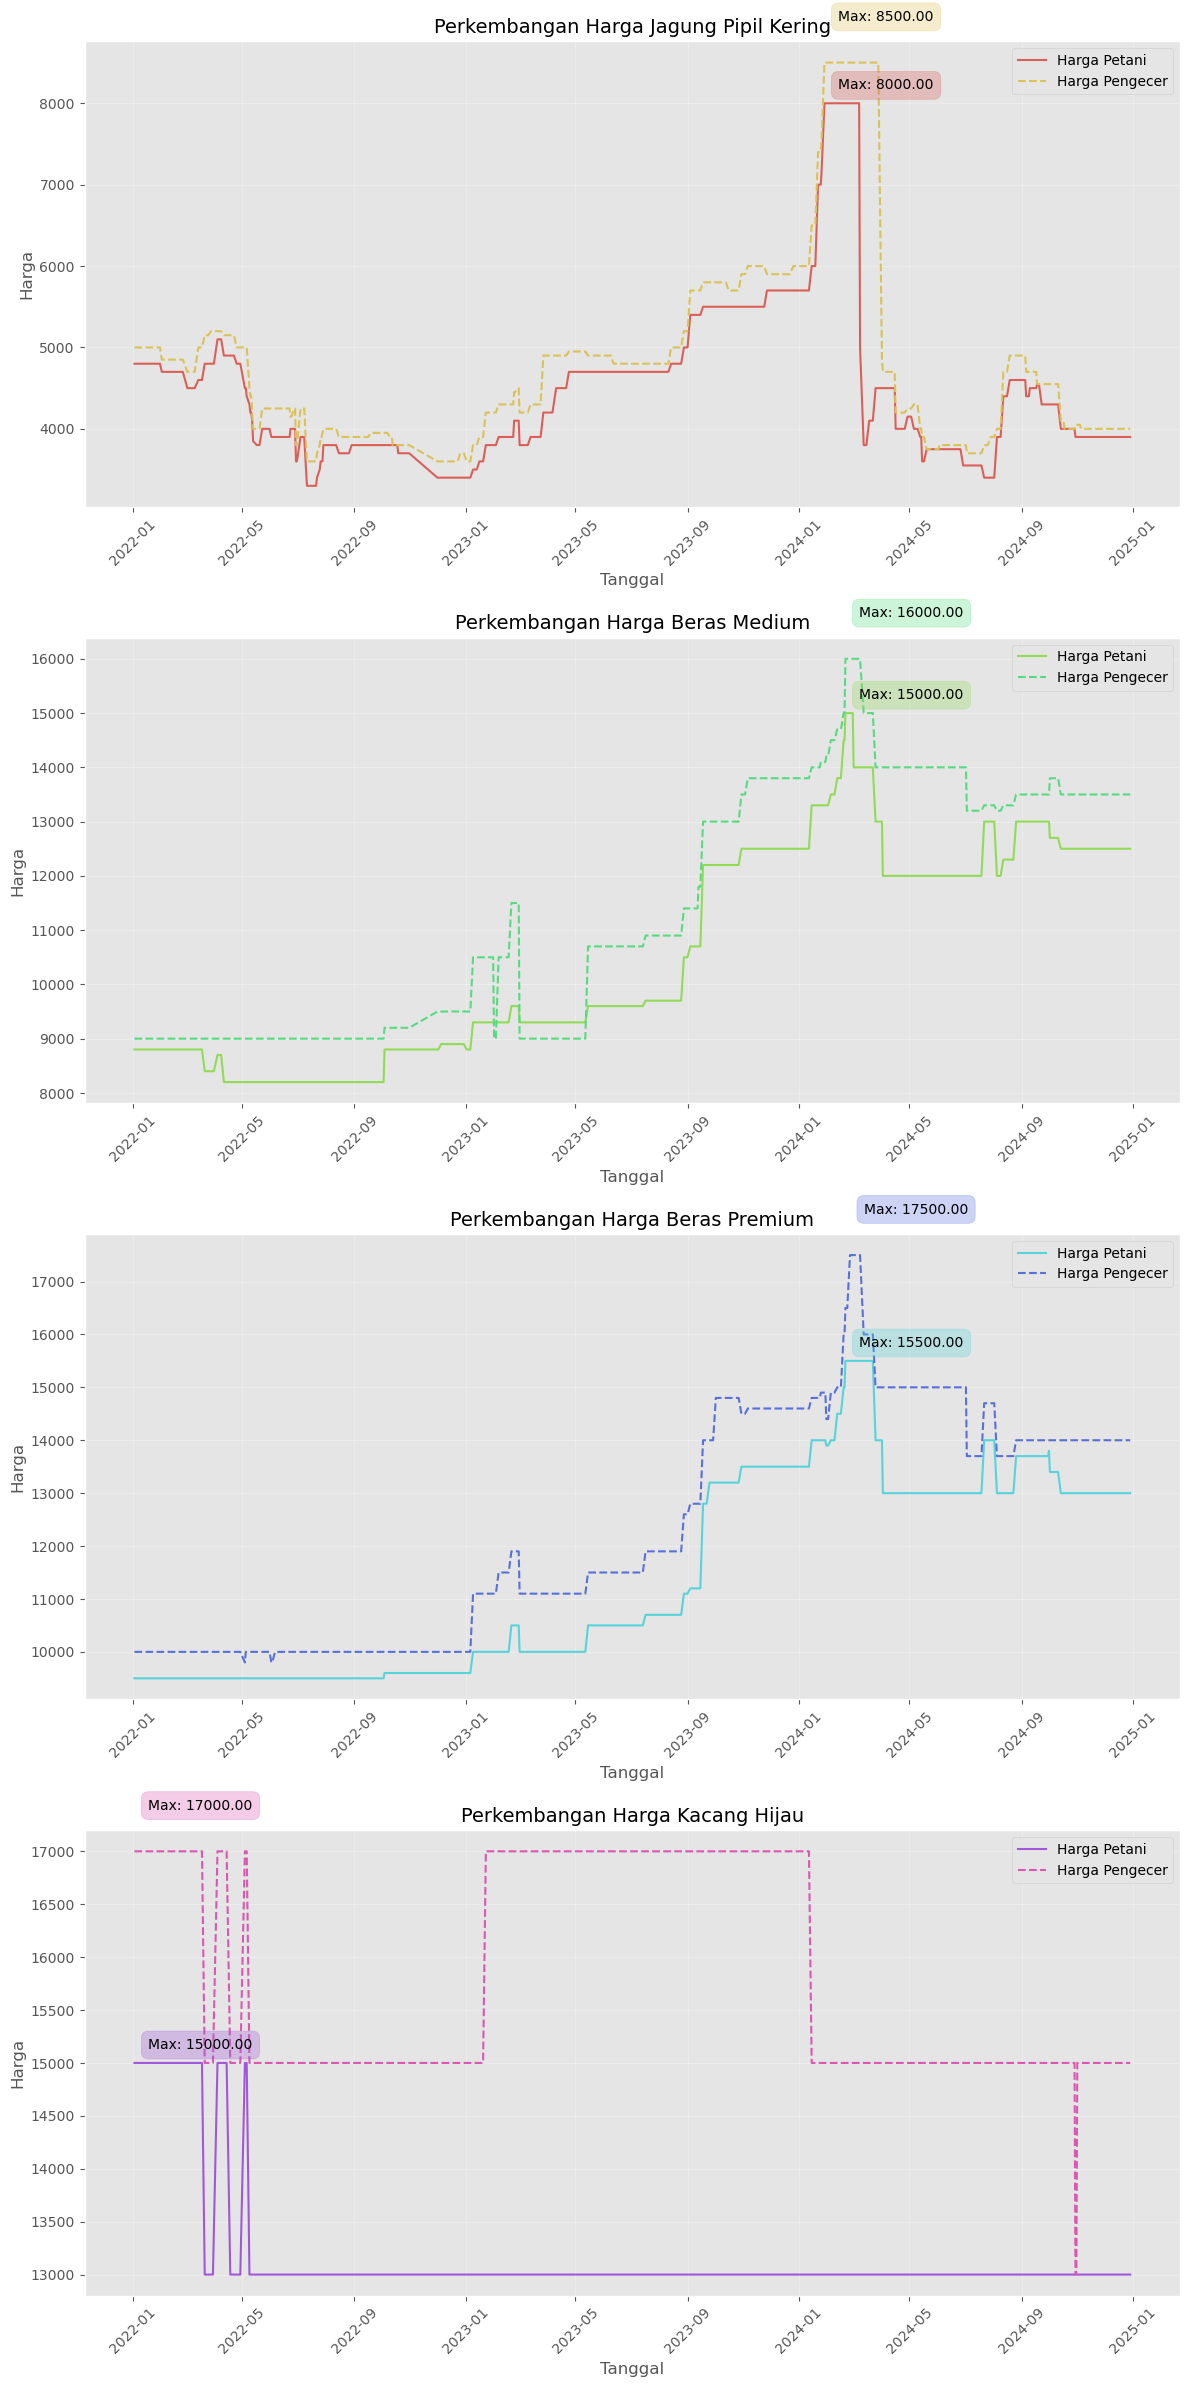

In [73]:
# Custom style
plt.style.use('ggplot')
colors = sns.color_palette("hls", 8)  # 8 warna berbeda untuk komoditas

# Daftar komoditas unik
komoditas_list = harga_df['Komoditi'].unique().to_pandas()

# Buat figure dengan subplot untuk setiap komoditas
fig, axes = plt.subplots(len(komoditas_list), 1, figsize=(12, 6*len(komoditas_list)))

# Plot per komoditas
for idx, komod in enumerate(komoditas_list):
    ax = axes[idx] if len(komoditas_list) > 1 else axes
    subset = harga_df[harga_df['Komoditi'] == komod]
    
    # Line plot
    sns.lineplot(data=subset.to_pandas(), 
                 x='Tanggal', y='Harga Petani', 
                 label='Harga Petani', color=colors[idx*2], ax=ax)
    sns.lineplot(data=subset.to_pandas(), 
                 x='Tanggal', y='Harga Pengecer', 
                 label='Harga Pengecer', color=colors[idx*2+1], linestyle='--', ax=ax)
    
    # Annotasi titik maksimum untuk Harga Petani
    max_petani = subset['Harga Petani'].max()
    max_date_petani = subset[subset['Harga Petani'] == max_petani]['Tanggal'].iloc[0]
    
    ax.annotate(f'Max: {max_petani:.2f}', 
                 xy=(max_date_petani, max_petani),
                 xytext=(10, 10), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', alpha=0.3, color=colors[idx*2]))
    
    # Annotasi titik maksimum untuk Harga Pengecer
    max_pengecer = subset['Harga Pengecer'].max()
    max_date_pengecer = subset[subset['Harga Pengecer'] == max_pengecer]['Tanggal'].iloc[0]
    
    ax.annotate(f'Max: {max_pengecer:.2f}', 
                 xy=(max_date_pengecer, max_pengecer),
                 xytext=(10, 30), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', alpha=0.3, color=colors[idx*2+1]))
    
    # Customisasi plot
    ax.set_title(f'Perkembangan Harga {komod}', fontsize=14)
    ax.set_xlabel('Tanggal', fontsize=12)
    ax.set_ylabel('Harga', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Rotasi label tanggal
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)

plt.tight_layout()
plt.show()


In [74]:
df = triwulan_df
df = df[df['Produksi'] > 0]

# Setting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12
palette = sns.color_palette("husl", 8)

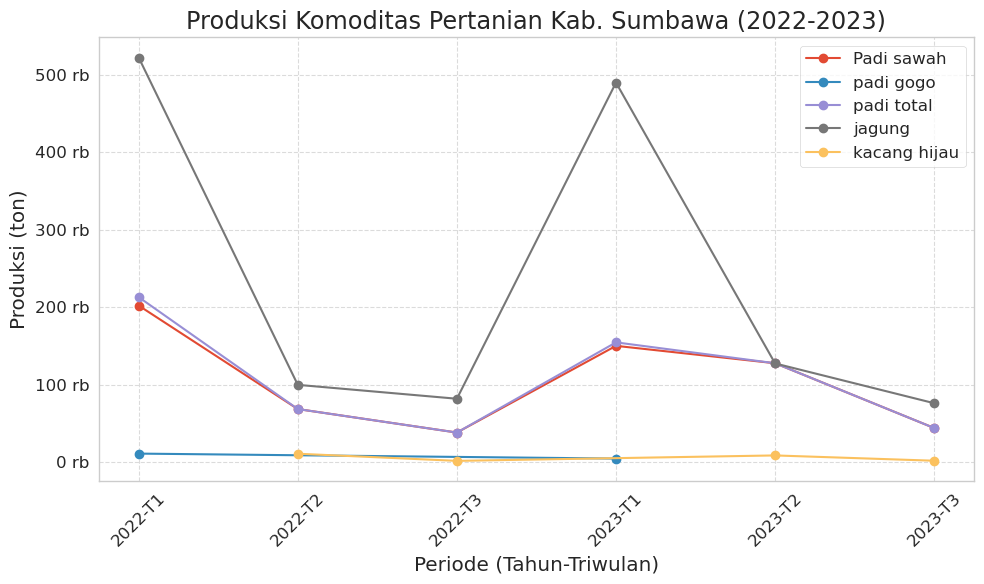

In [75]:
from matplotlib.ticker import FuncFormatter

def thousand_formatter(x, pos):
    return f'{x/1000:,.0f} rb'
formatter = FuncFormatter(thousand_formatter)



# 1. Grafik Produksi Per Komoditas per Tahun
plt.figure(figsize=(10, 6), tight_layout=True)
# Gabungkan tahun dan triwulan untuk sumbu x
df['periode'] = df['tahun'].astype(str) + "-T" + df['triwulan'].astype(str)
# Plot untuk setiap komoditas
for komoditas in df['Komoditi'].unique().to_pandas():
    komoditas_df = df[df['Komoditi'] == komoditas]
    plt.plot(komoditas_df['periode'], komoditas_df['Produksi'], 'o-', label=komoditas)
plt.gca().yaxis.set_major_formatter(formatter)
plt.title('Produksi Komoditas Pertanian Kab. Sumbawa (2022-2023)')
plt.xlabel('Periode (Tahun-Triwulan)')
plt.ylabel('Produksi (ton)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

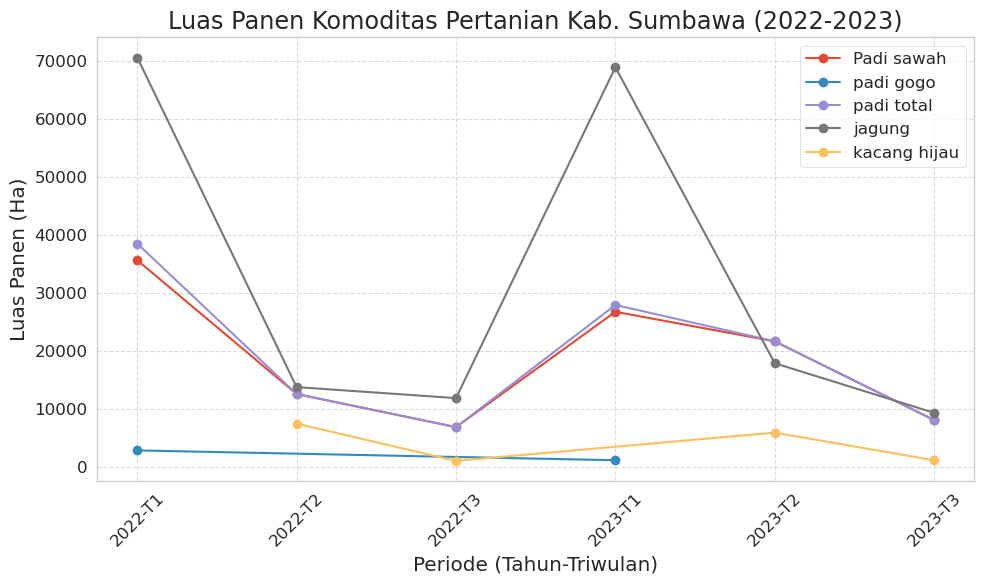

In [76]:
# 1. Grafik Produksi Per Komoditas per Tahun
plt.figure(figsize=(10, 6), tight_layout=True)
# Gabungkan tahun dan triwulan untuk sumbu x
df['periode'] = df['tahun'].astype(str) + "-T" + df['triwulan'].astype(str)
# Plot untuk setiap komoditas
for komoditas in df['Komoditi'].unique().to_pandas():
    komoditas_df = df[df['Komoditi'] == komoditas]
    plt.plot(komoditas_df['periode'], komoditas_df['Luas Panen'], 'o-', label=komoditas)
plt.title('Luas Panen Komoditas Pertanian Kab. Sumbawa (2022-2023)')
plt.xlabel('Periode (Tahun-Triwulan)')
plt.ylabel('Luas Panen (Ha)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

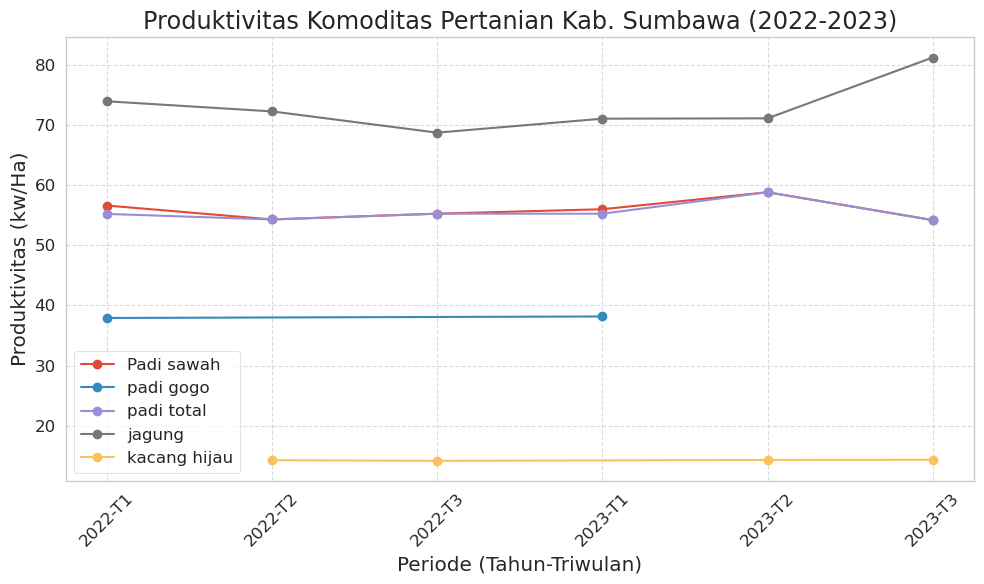

In [77]:
# 1. Grafik Produksi Per Komoditas per Tahun
plt.figure(figsize=(10, 6), tight_layout=True)
# Gabungkan tahun dan triwulan untuk sumbu x
df['periode'] = df['tahun'].astype(str) + "-T" + df['triwulan'].astype(str)
# Plot untuk setiap komoditas
for komoditas in df['Komoditi'].unique().to_pandas():
    komoditas_df = df[df['Komoditi'] == komoditas]
    plt.plot(komoditas_df['periode'], komoditas_df['Produktivitas'], 'o-', label=komoditas)
plt.title('Produktivitas Komoditas Pertanian Kab. Sumbawa (2022-2023)')
plt.xlabel('Periode (Tahun-Triwulan)')
plt.ylabel('Produktivitas (kw/Ha)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

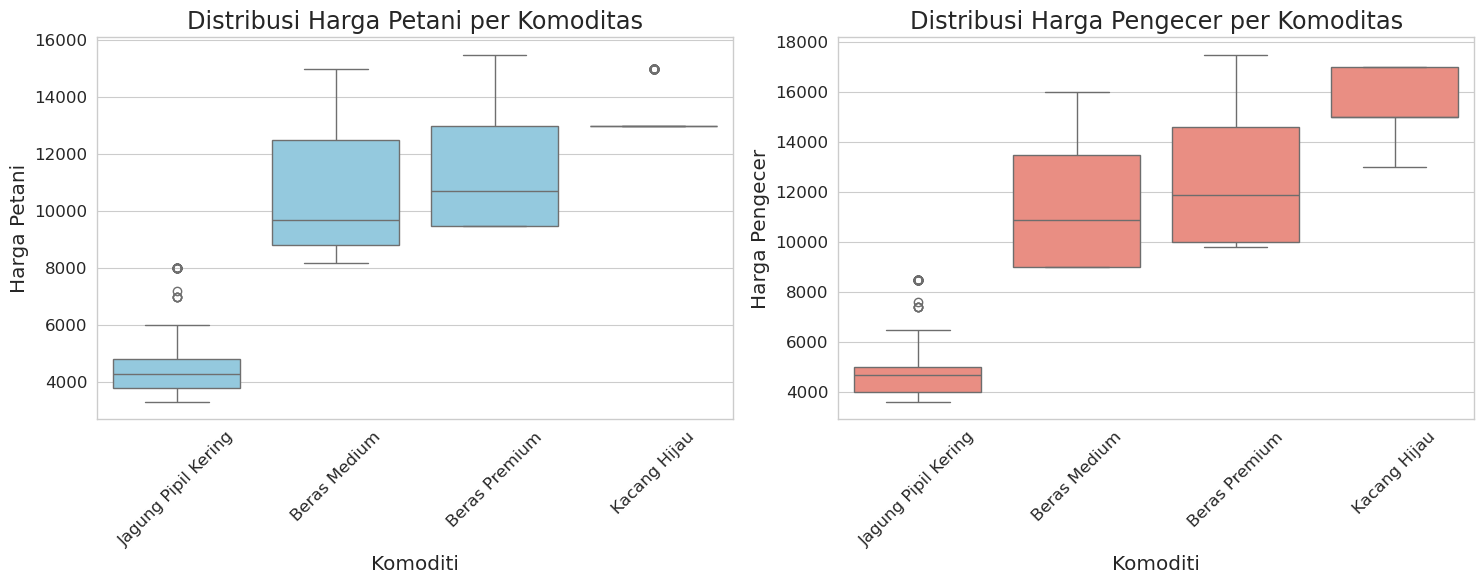

In [78]:
plt.figure(figsize=(15, 6))

# Boxplot Harga Petani per Komoditas
plt.subplot(1, 2, 1)
sns.boxplot(data=harga_df.to_pandas(), 
           x='Komoditi', y='Harga Petani',
           color='skyblue')
plt.title('Distribusi Harga Petani per Komoditas')
plt.xticks(rotation=45)

# Boxplot Harga Pengecer per Komoditas
plt.subplot(1, 2, 2)
sns.boxplot(data=harga_df.to_pandas(), 
           x='Komoditi', y='Harga Pengecer',
           color='salmon')
plt.title('Distribusi Harga Pengecer per Komoditas')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [79]:
triwulan_df.columns

Index(['Komoditi', 'tahun', 'triwulan', 'Luas Panen', 'Produktivitas',
       'Produksi'],
      dtype='object')

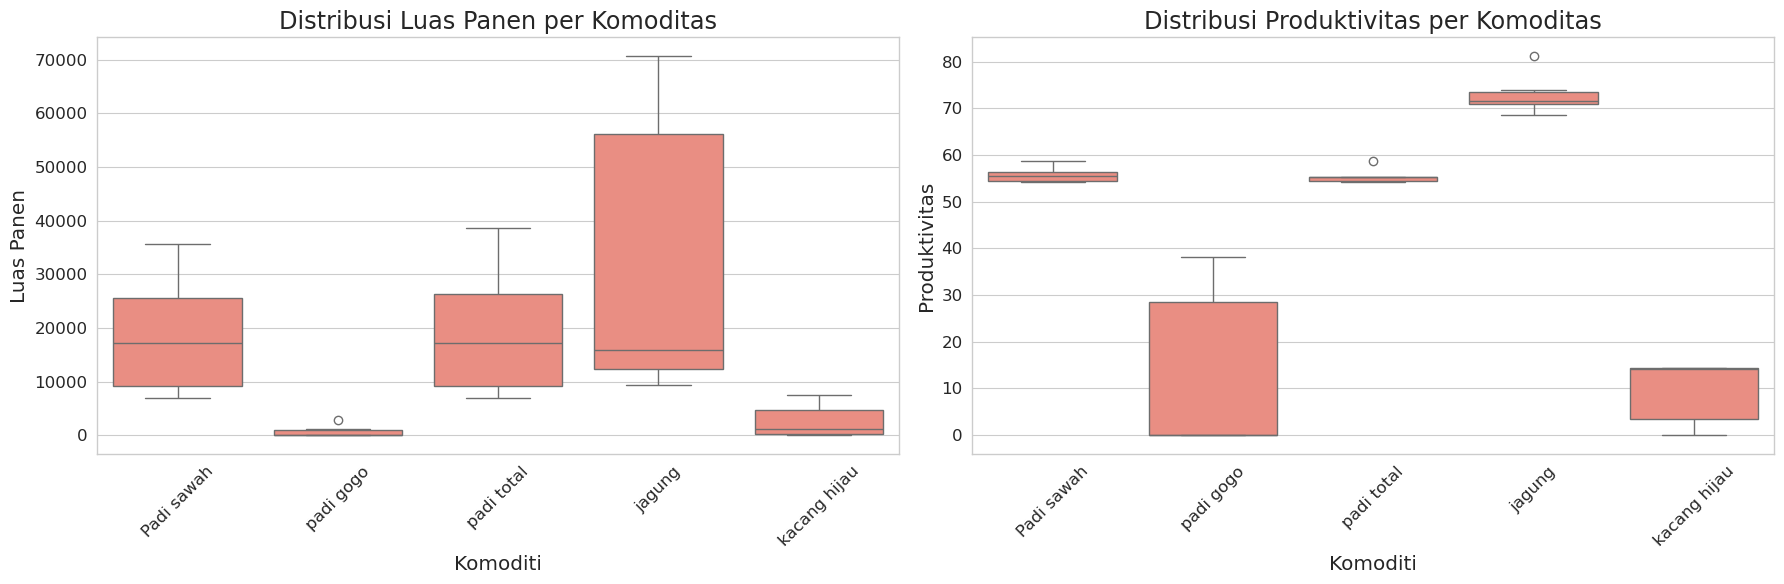

In [80]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=triwulan_df.to_pandas(), 
           x='Komoditi', y='Luas Panen',
           color='salmon')
plt.title('Distribusi Luas Panen per Komoditas')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(data=triwulan_df.to_pandas(), 
           x='Komoditi', y='Produktivitas',
           color='salmon')
plt.title('Distribusi Produktivitas per Komoditas')
plt.xticks(rotation=45)


plt.tight_layout()
plt.show()

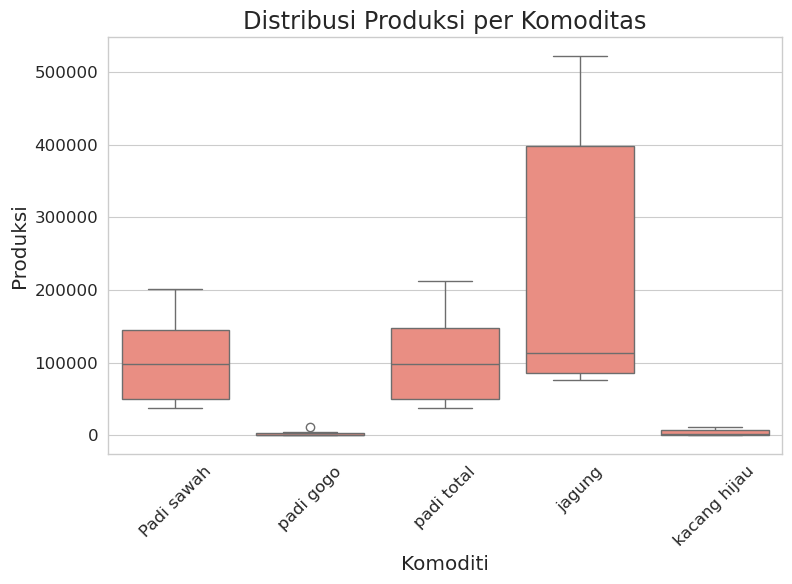

In [81]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=triwulan_df.to_pandas(), 
           x='Komoditi', y='Produksi',
           color='salmon')
plt.title('Distribusi Produksi per Komoditas')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [82]:
q1_2022_start = pd.to_datetime('2022-01-01')
q1_2022_end = pd.to_datetime('2022-04-30')

q2_2022_start = pd.to_datetime('2022-05-01')
q2_2022_end = pd.to_datetime('2022-08-31')

q3_2022_start = pd.to_datetime('2022-09-01')
q3_2022_end = pd.to_datetime('2022-12-31')

q1_2023_start = pd.to_datetime('2023-01-01')
q1_2023_end = pd.to_datetime('2023-04-30')

q2_2023_start = pd.to_datetime('2023-05-01')
q2_2023_end = pd.to_datetime('2023-08-31')

q3_2023_start = pd.to_datetime('2023-09-01')
q3_2023_end = pd.to_datetime('2023-12-31')

q1_2024_start = pd.to_datetime('2024-01-01')
q1_2024_end = pd.to_datetime('2024-04-30')

q2_2024_start = pd.to_datetime('2024-05-01')
q2_2024_end = pd.to_datetime('2024-08-31')

q3_2024_start = pd.to_datetime('2024-09-01')
q3_2024_end = pd.to_datetime('2024-12-31')

In [83]:
harga_df.loc[(harga_df['Tanggal'] >= q1_2022_start) & (harga_df['Tanggal'] <= q1_2022_end), 'Periode'] = 'Q1-2022'
harga_df.loc[(harga_df['Tanggal'] >= q2_2022_start) & (harga_df['Tanggal'] <= q2_2022_end), 'Periode'] = 'Q2-2022'
harga_df.loc[(harga_df['Tanggal'] >= q3_2022_start) & (harga_df['Tanggal'] <= q3_2022_end), 'Periode'] = 'Q3-2022'

harga_df.loc[(harga_df['Tanggal'] >= q1_2023_start) & (harga_df['Tanggal'] <= q1_2023_end), 'Periode'] = 'Q1-2023'
harga_df.loc[(harga_df['Tanggal'] >= q2_2023_start) & (harga_df['Tanggal'] <= q2_2023_end), 'Periode'] = 'Q2-2023'
harga_df.loc[(harga_df['Tanggal'] >= q3_2023_start) & (harga_df['Tanggal'] <= q3_2023_end), 'Periode'] = 'Q3-2023'

harga_df.loc[(harga_df['Tanggal'] >= q1_2024_start) & (harga_df['Tanggal'] <= q1_2024_end), 'Periode'] = 'Q1-2024'
harga_df.loc[(harga_df['Tanggal'] >= q2_2024_start) & (harga_df['Tanggal'] <= q2_2024_end), 'Periode'] = 'Q2-2024'
harga_df.loc[(harga_df['Tanggal'] >= q3_2024_start) & (harga_df['Tanggal'] <= q3_2024_end), 'Periode'] = 'Q3-2024'

In [84]:
triwulan_df['Tipe'] = 'Undefined'

In [85]:
harga_df['Tipe'] = 'Undefined'

In [86]:
harga_df['Komoditi'] = harga_df['Komoditi'].replace('Jagung Pipil Kering', 'Jagung')

In [87]:
triwulan_df.loc[(triwulan_df['Komoditi'] == 'Padi sawah'), 'Tipe'] = 'Padi sawah'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'padi gogo'), 'Tipe'] = 'Padi sawah'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'padi total'), 'Tipe'] = 'Padi'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'jagung'), 'Tipe'] = 'Jagung'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'kacang hijau'), 'Tipe'] = 'Kacang Hijau'

harga_df.loc[(harga_df['Komoditi'] == 'Beras Medium'), 'Tipe'] = 'Padi'
harga_df.loc[(harga_df['Komoditi'] == 'Beras Premium'), 'Tipe'] = 'Padi'
harga_df.loc[(harga_df['Komoditi'] == 'Jagung'), 'Tipe'] = 'Jagung'
harga_df.loc[(harga_df['Komoditi'] == 'Kacang Hijau'), 'Tipe'] = 'Kacang Hijau'

In [88]:
triwulan_df['Periode'] = "Q" + triwulan_df['triwulan'].astype(str) + "-" + triwulan_df['tahun'].astype(str)

In [89]:
harga_df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Periode,Tipe
0,Jagung,2022-01-03,4800,5000,Q1-2022,Jagung
1,Jagung,2022-01-04,4800,5000,Q1-2022,Jagung
2,Jagung,2022-01-05,4800,5000,Q1-2022,Jagung
3,Jagung,2022-01-06,4800,5000,Q1-2022,Jagung
4,Jagung,2022-01-07,4800,5000,Q1-2022,Jagung
...,...,...,...,...,...,...
4377,Jagung,2024-12-27,3900,4000,Q3-2024,Jagung
4378,Jagung,2024-12-28,3900,4000,Q3-2024,Jagung
4379,Jagung,2024-12-29,3900,4000,Q3-2024,Jagung
4380,Jagung,2024-12-30,<NA>,<NA>,Q3-2024,Jagung


In [90]:
harga_df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Periode,Tipe
0,Jagung,2022-01-03,4800,5000,Q1-2022,Jagung
1,Jagung,2022-01-04,4800,5000,Q1-2022,Jagung
2,Jagung,2022-01-05,4800,5000,Q1-2022,Jagung
3,Jagung,2022-01-06,4800,5000,Q1-2022,Jagung
4,Jagung,2022-01-07,4800,5000,Q1-2022,Jagung
...,...,...,...,...,...,...
4377,Jagung,2024-12-27,3900,4000,Q3-2024,Jagung
4378,Jagung,2024-12-28,3900,4000,Q3-2024,Jagung
4379,Jagung,2024-12-29,3900,4000,Q3-2024,Jagung
4380,Jagung,2024-12-30,<NA>,<NA>,Q3-2024,Jagung


In [91]:
df = cudf.merge(
    harga_df,
    triwulan_df,
    left_on=['Periode', 'Tipe'], # Kolom dari df_penjualan
    right_on=['Periode', 'Tipe'],       # Kolom dari df_kehadiran
    how='left'                               # Pilih jenis join sesuai kebutuhanmu
)

In [92]:
explore_harga_data(df)

1. Kolom dan Tipe Data:
Komoditi_x                object
Tanggal           datetime64[ns]
Harga Petani               int64
Harga Pengecer             int64
Periode                   object
Tipe                      object
Komoditi_y                object
tahun                      int64
triwulan                   int64
Luas Panen               float64
Produktivitas            float64
Produksi                 float64
dtype: object


2. Jumlah Data Duplikat: 0


3. Missing Values:
Harga Petani      1440
Harga Pengecer    1439
Komoditi_y        1464
tahun             1464
triwulan          1464
Luas Panen        1464
Produktivitas     1464
Produksi          1464
dtype: int64


4. Ringkasan Statistik (Data Numerik):
                             Tanggal  Harga Petani  Harga Pengecer  \
count                           4382   2942.000000     2943.000000   
mean   2023-07-02 17:59:30.424463616   9954.928620    11163.098879   
min              2022-01-01 00:00:00   3300.000000     3600.000000  

In [93]:
df

,Komoditi_x,Tanggal,Harga Petani,Harga Pengecer,Periode,Tipe,Komoditi_y,tahun,triwulan,Luas Panen,Produktivitas,Produksi
0,Beras Medium,2024-08-27,13000,13500,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,Beras Medium,2024-08-28,13000,13500,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,Beras Medium,2024-08-29,<NA>,<NA>,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,Beras Medium,2024-08-30,<NA>,<NA>,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,Beras Medium,2024-08-31,<NA>,<NA>,Q2-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...
4377,Jagung,2022-09-11,<NA>,<NA>,Q3-2022,Jagung,jagung,2022,3,11893.0081,68.69,81693.07264
4378,Jagung,2022-09-12,3800,3900,Q3-2022,Jagung,jagung,2022,3,11893.0081,68.69,81693.07264
4379,Jagung,2022-09-13,3800,3900,Q3-2022,Jagung,jagung,2022,3,11893.0081,68.69,81693.07264
4380,Jagung,2022-09-14,3800,3900,Q3-2022,Jagung,jagung,2022,3,11893.0081,68.69,81693.07264


In [94]:
df=df.sort_values(by='Tanggal')
df=df.reset_index()
df=df.drop(columns=['index', 'triwulan'])
df

,Komoditi_x,Tanggal,Harga Petani,Harga Pengecer,Periode,Tipe,Komoditi_y,tahun,Luas Panen,Produktivitas,Produksi
0,Beras Premium,2022-01-01,<NA>,<NA>,Q1-2022,Padi,padi total,2022,38556.62,55.20358781,212846.3758
1,Beras Medium,2022-01-01,<NA>,<NA>,Q1-2022,Padi,padi total,2022,38556.62,55.20358781,212846.3758
2,Kacang Hijau,2022-01-01,<NA>,<NA>,Q1-2022,Kacang Hijau,kacang hijau,2022,0.0,0.0,0.0
3,Beras Premium,2022-01-02,<NA>,<NA>,Q1-2022,Padi,padi total,2022,38556.62,55.20358781,212846.3758
4,Beras Medium,2022-01-02,<NA>,<NA>,Q1-2022,Padi,padi total,2022,38556.62,55.20358781,212846.3758
...,...,...,...,...,...,...,...,...,...,...,...
4377,Kacang Hijau,2024-12-30,<NA>,<NA>,Q3-2024,Kacang Hijau,<NA>,<NA>,<NA>,<NA>,<NA>
4378,Kacang Hijau,2024-12-31,<NA>,<NA>,Q3-2024,Kacang Hijau,<NA>,<NA>,<NA>,<NA>,<NA>
4379,Beras Medium,2024-12-31,<NA>,<NA>,Q3-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>
4380,Beras Premium,2024-12-31,<NA>,<NA>,Q3-2024,Padi,<NA>,<NA>,<NA>,<NA>,<NA>


In [95]:
df.isnull().sum()

Komoditi_x           0
Tanggal              0
Harga Petani      1440
Harga Pengecer    1439
Periode              0
Tipe                 0
Komoditi_y        1464
tahun             1464
Luas Panen        1464
Produktivitas     1464
Produksi          1464
dtype: int64

In [96]:
df=df.drop(columns=['Komoditi_y'])
df = df.rename(columns={'Komoditi_x' : 'Komoditi'})
df=df.to_pandas()

In [97]:
df=df.drop(columns=['tahun'])

In [98]:
# 1. Hari dalam sebulan (Day)
df['Hari'] = df['Tanggal'].dt.day

# 2. Bulan (Month)
df['Bulan'] = df['Tanggal'].dt.month

# 3. Tahun (Year)
df['Tahun'] = df['Tanggal'].dt.year

In [99]:
df.columns

Index(['Komoditi', 'Tanggal', 'Harga Petani', 'Harga Pengecer', 'Periode',
       'Tipe', 'Luas Panen', 'Produktivitas', 'Produksi', 'Hari', 'Bulan',
       'Tahun'],
      dtype='object')

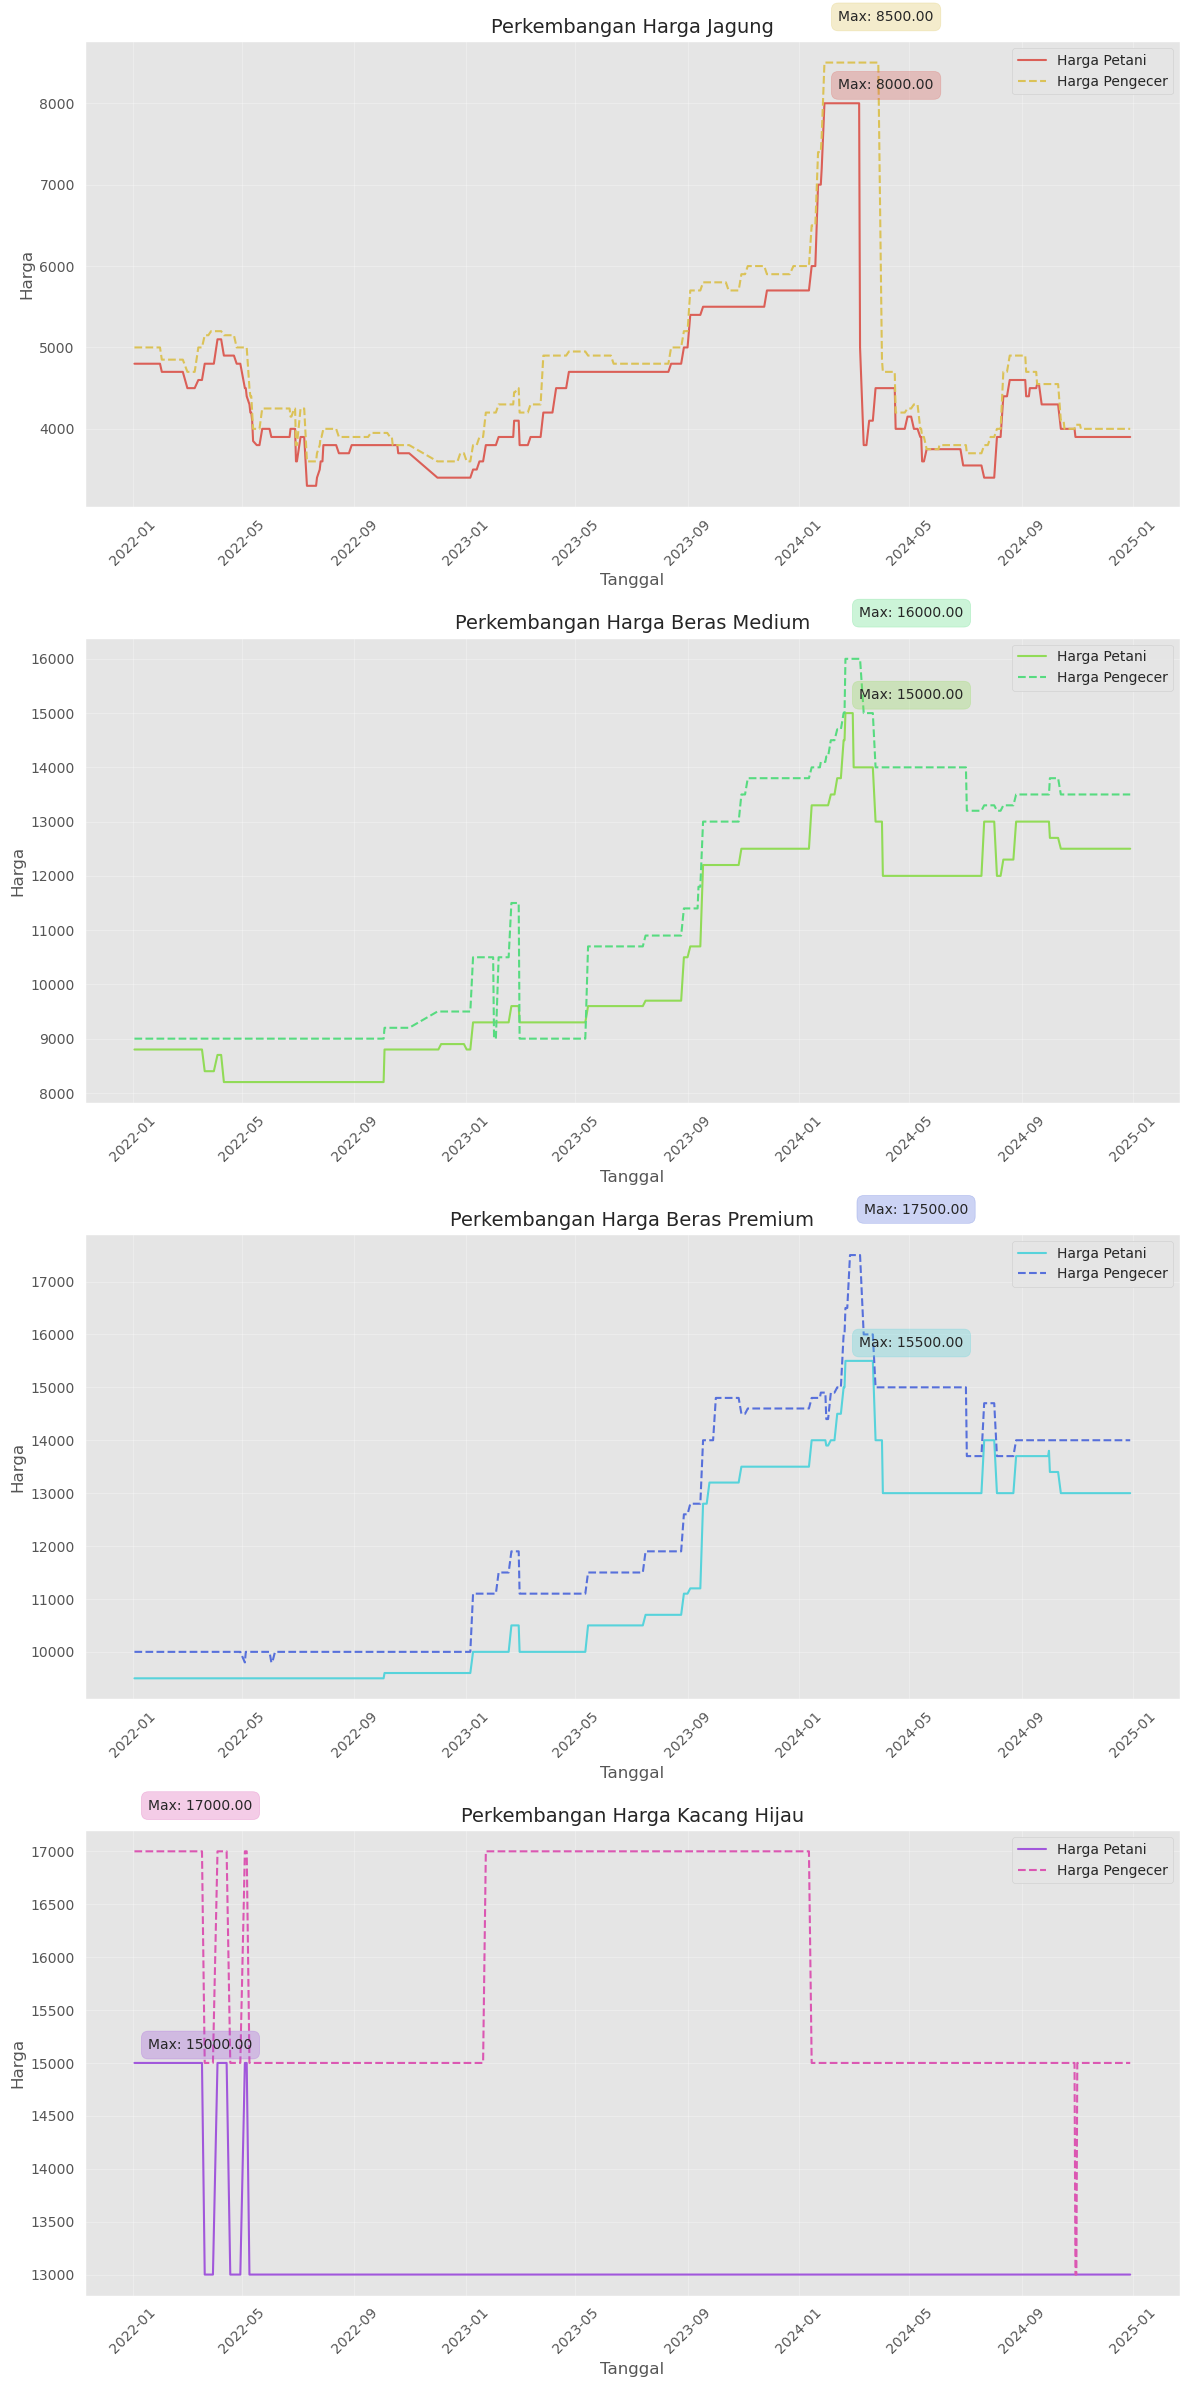

In [100]:
# Custom style
plt.style.use('ggplot')
colors = sns.color_palette("hls", 8)  # 8 warna berbeda untuk komoditas

# Daftar komoditas unik
komoditas_list = harga_df['Komoditi'].unique().to_pandas()

# Buat figure dengan subplot untuk setiap komoditas
fig, axes = plt.subplots(len(komoditas_list), 1, figsize=(12, 6*len(komoditas_list)))

# Plot per komoditas
for idx, komod in enumerate(komoditas_list):
    ax = axes[idx] if len(komoditas_list) > 1 else axes
    subset = harga_df[harga_df['Komoditi'] == komod]
    
    # Line plot
    sns.lineplot(data=subset.to_pandas(), 
                 x='Tanggal', y='Harga Petani', 
                 label='Harga Petani', color=colors[idx*2], ax=ax)
    sns.lineplot(data=subset.to_pandas(), 
                 x='Tanggal', y='Harga Pengecer', 
                 label='Harga Pengecer', color=colors[idx*2+1], linestyle='--', ax=ax)
    
    # Annotasi titik maksimum untuk Harga Petani
    max_petani = subset['Harga Petani'].max()
    max_date_petani = subset[subset['Harga Petani'] == max_petani]['Tanggal'].iloc[0]
    
    ax.annotate(f'Max: {max_petani:.2f}', 
                 xy=(max_date_petani, max_petani),
                 xytext=(10, 10), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', alpha=0.3, color=colors[idx*2]))
    
    # Annotasi titik maksimum untuk Harga Pengecer
    max_pengecer = subset['Harga Pengecer'].max()
    max_date_pengecer = subset[subset['Harga Pengecer'] == max_pengecer]['Tanggal'].iloc[0]
    
    ax.annotate(f'Max: {max_pengecer:.2f}', 
                 xy=(max_date_pengecer, max_pengecer),
                 xytext=(10, 30), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.5', alpha=0.3, color=colors[idx*2+1]))
    
    # Customisasi plot
    ax.set_title(f'Perkembangan Harga {komod}', fontsize=14)
    ax.set_xlabel('Tanggal', fontsize=12)
    ax.set_ylabel('Harga', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Rotasi label tanggal
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)

plt.tight_layout()
plt.show()


In [101]:
from sklearn.preprocessing import OneHotEncoder

In [102]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
komoditi_encoded = encoder.fit_transform(df[['Komoditi']])
encoded_df = pd.DataFrame(komoditi_encoded, columns=encoder.get_feature_names_out(['Komoditi']))
df.reset_index(drop=True, inplace=True) # Reset indeks df jika ada potensi ketidakcocokan
encoded_df.reset_index(drop=True, inplace=True) # Reset indeks encoded_df
df_encoded = pd.concat([df, encoded_df], axis=1)


In [103]:
df_encoded

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Periode,Tipe,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun,Komoditi_Beras Medium,Komoditi_Beras Premium,Komoditi_Jagung,Komoditi_Kacang Hijau
0,Beras Premium,2022-01-01,NaN,NaN,Q1-2022,Padi,38556.62,55.203588,212846.3758,1,1,2022,0.0,1.0,0.0,0.0
1,Beras Medium,2022-01-01,NaN,NaN,Q1-2022,Padi,38556.62,55.203588,212846.3758,1,1,2022,1.0,0.0,0.0,0.0
2,Kacang Hijau,2022-01-01,NaN,NaN,Q1-2022,Kacang Hijau,0.00,0.000000,0.0000,1,1,2022,0.0,0.0,0.0,1.0
3,Beras Premium,2022-01-02,NaN,NaN,Q1-2022,Padi,38556.62,55.203588,212846.3758,2,1,2022,0.0,1.0,0.0,0.0
4,Beras Medium,2022-01-02,NaN,NaN,Q1-2022,Padi,38556.62,55.203588,212846.3758,2,1,2022,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4377,Kacang Hijau,2024-12-30,NaN,NaN,Q3-2024,Kacang Hijau,NaN,NaN,NaN,30,12,2024,0.0,0.0,0.0,1.0
4378,Kacang Hijau,2024-12-31,NaN,NaN,Q3-2024,Kacang Hijau,NaN,NaN,NaN,31,12,2024,0.0,0.0,0.0,1.0
4379,Beras Medium,2024-12-31,NaN,NaN,Q3-2024,Padi,NaN,NaN,NaN,31,12,2024,1.0,0.0,0.0,0.0
4380,Beras Premium,2024-12-31,NaN,NaN,Q3-2024,Padi,NaN,NaN,NaN,31,12,2024,0.0,1.0,0.0,0.0


In [104]:
df_encoded=df_encoded

In [105]:
corr_check=[
    'Komoditi_Beras Medium',
    'Komoditi_Beras Premium',
    'Komoditi_Jagung',
    'Komoditi_Kacang Hijau',
    'Harga Petani',
    'Harga Pengecer',
    'Luas Panen',
    'Produktivitas',
    'Produksi',
    'Tanggal'
]

Text(0.5, 1.0, 'Korelasi')

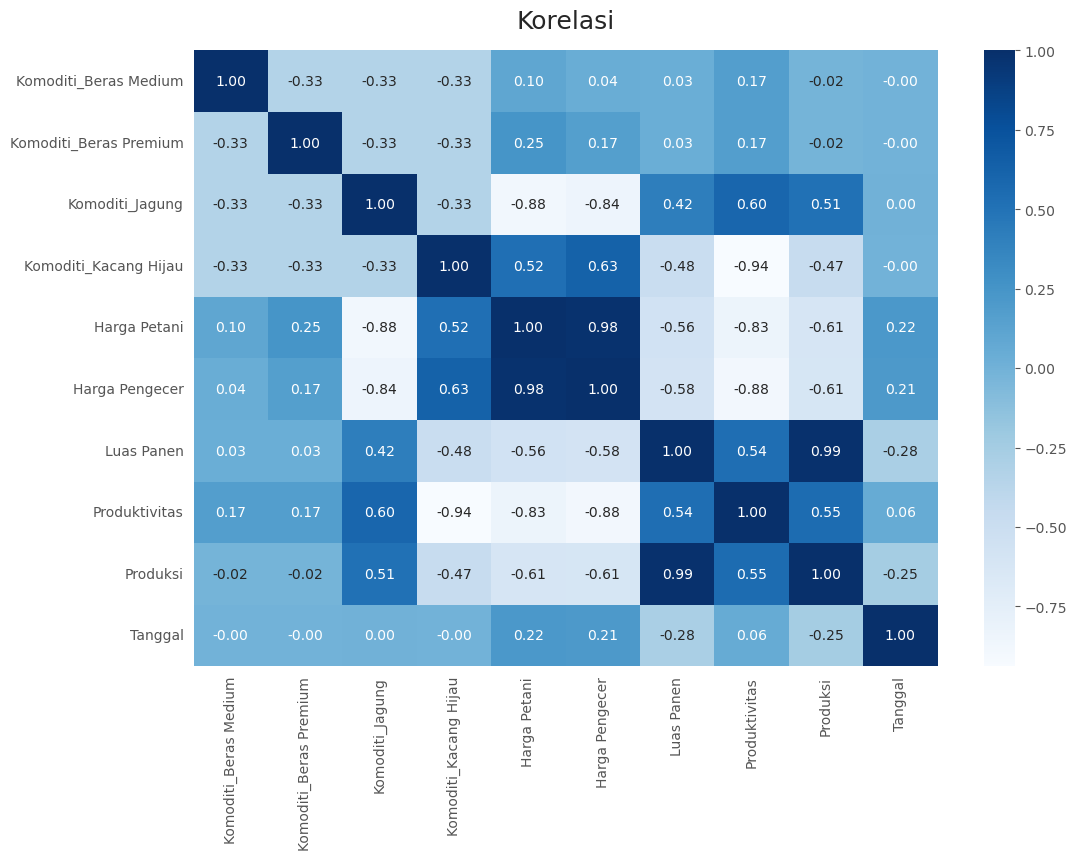

In [106]:
heatmaps=sns.heatmap(df_encoded[corr_check].corr(),cmap='Blues', annot=True, fmt='.2f')
heatmaps.set_title('Korelasi', fontdict={'fontsize':18}, pad=16)